# CMPT 401 Final Project
# Gnana Damarla
# 649095
## Techno Wiz University Student Registration Analysis

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load data
students = pd.read_csv('students.csv')
regs = pd.read_csv('course_registrations.csv')
res = pd.read_csv('residency.csv')

print('students:', students.shape)
print('course_registrations:', regs.shape)
print('residency:', res.shape)

students: (5000, 10)
course_registrations: (22653, 7)
residency: (5000, 8)


---
# Section 1: Student Demographics & Academic Patterns (5 marks)

## Descriptive (3 marks)

### Q1a: Demographic distribution by gender, ethnicity, citizenship, and program

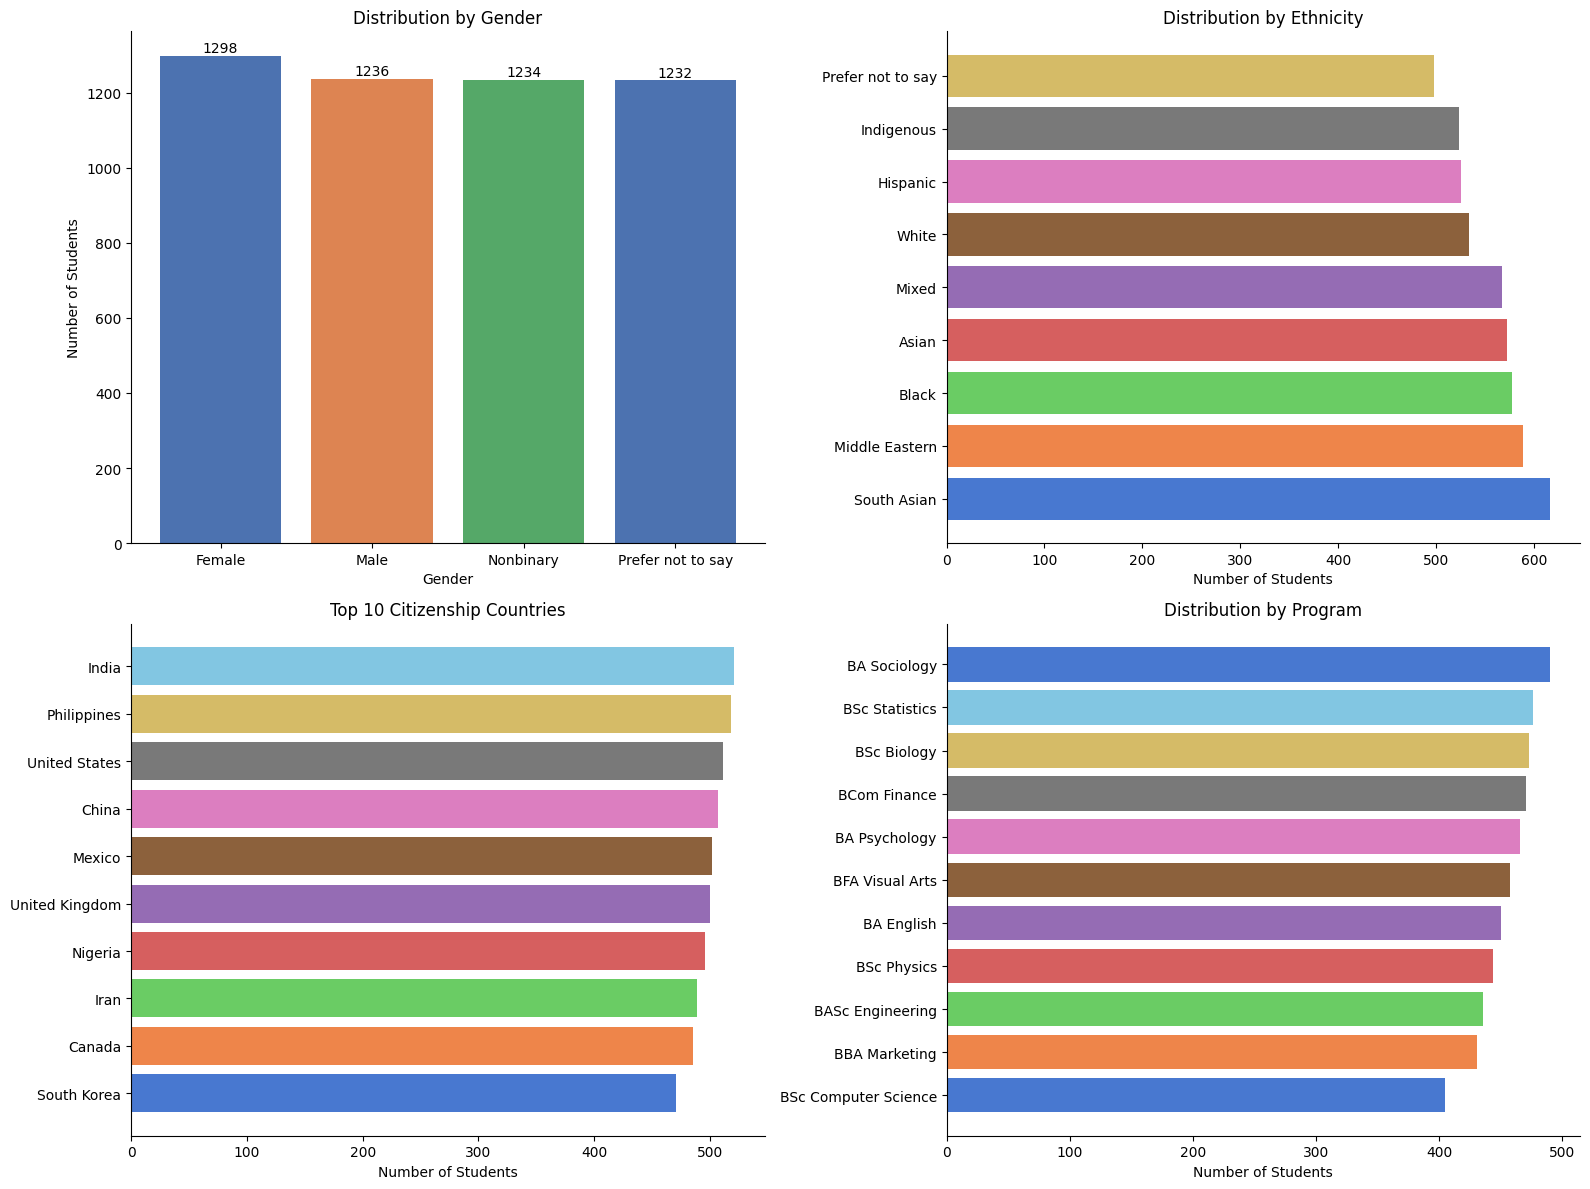

Gender distribution:
gender
Female               1298
Male                 1236
Nonbinary            1234
Prefer not to say    1232
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
South Asian          616
Middle Eastern       589
Black                577
Asian                572
Mixed                567
White                533
Hispanic             525
Indigenous           523
Prefer not to say    498
Name: count, dtype: int64

Program distribution:
program
BA Sociology            490
BSc Statistics          476
BSc Biology             473
BCom Finance            471
BA Psychology           466
BFA Visual Arts         458
BA English              450
BSc Physics             444
BASc Engineering        436
BBA Marketing           431
BSc Computer Science    405
Name: count, dtype: int64


In [66]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender
gender_counts = students['gender'].value_counts()
axes[0,0].bar(gender_counts.index, gender_counts.values, color=['#4C72B0','#DD8452','#55A868'])
axes[0,0].set_title('Distribution by Gender')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Number of Students')
for i, v in enumerate(gender_counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center')

# Ethnicity
eth_counts = students['ethnicity'].value_counts()
axes[0,1].barh(eth_counts.index, eth_counts.values, color=sns.color_palette('muted', len(eth_counts)))
axes[0,1].set_title('Distribution by Ethnicity')
axes[0,1].set_xlabel('Number of Students')

# Citizenship (top 10)
cit_counts = students['citizenship'].value_counts().head(10)
axes[1,0].barh(cit_counts.index[::-1], cit_counts.values[::-1], color=sns.color_palette('muted', 10))
axes[1,0].set_title('Top 10 Citizenship Countries')
axes[1,0].set_xlabel('Number of Students')

# Program
prog_counts = students['program'].value_counts()
axes[1,1].barh(prog_counts.index[::-1], prog_counts.values[::-1], color=sns.color_palette('muted', len(prog_counts)))
axes[1,1].set_title('Distribution by Program')
axes[1,1].set_xlabel('Number of Students')

plt.tight_layout()
plt.show()

print('Gender distribution:')
print(gender_counts)
print('\nEthnicity distribution:')
print(eth_counts)
print('\nProgram distribution:')
print(prog_counts)

Answer: The student body shows a fairly even gender split with slight variation. Ethnicity is diverse with multiple groups represented. Canada is the most common citizenship, followed by other countries. Programs are relatively evenly distributed across the 10 offered degrees.

### Q1b: How does year of study vary across programs?

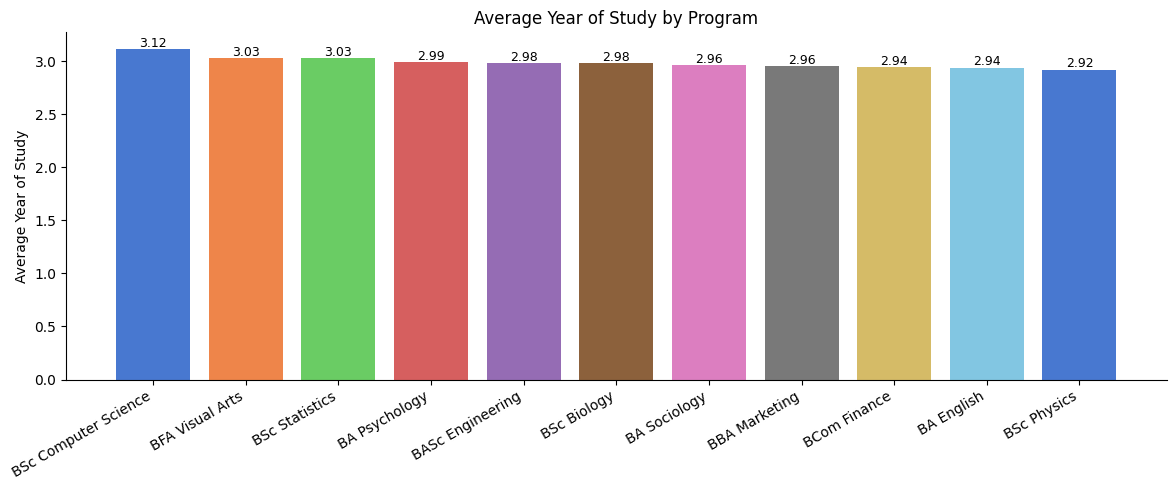

Year of study distribution by program:
program        BA English  BA Psychology  BA Sociology  BASc Engineering  \
year_of_study                                                              
1                      96             87           108                94   
2                     100            109           105                77   
3                      74             83            71                98   
4                      95             95           109                77   
5                      85             92            97                90   

program        BBA Marketing  BCom Finance  BFA Visual Arts  BSc Biology  \
year_of_study                                                              
1                        101           108               88           92   
2                         79            92               96           92   
3                         76            88               89          105   
4                         88            86      

In [67]:
year_prog = students.groupby('program')['year_of_study'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(range(len(year_prog)), year_prog.values, color=sns.color_palette('muted', len(year_prog)))
plt.xticks(range(len(year_prog)), year_prog.index, rotation=30, ha='right')
plt.ylabel('Average Year of Study')
plt.title('Average Year of Study by Program')
for i, v in enumerate(year_prog.values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

year_prog_dist = students.pivot_table(index='year_of_study', columns='program', aggfunc='size', fill_value=0)
print('Year of study distribution by program:')
print(year_prog_dist)

Answer: Year of study distribution is fairly consistent across programs, with all programs spanning years 1 through 5. The average year of study is close to 3 for most programs, suggesting students are spread evenly across years.

### Q1c: Proportion of international vs. domestic students

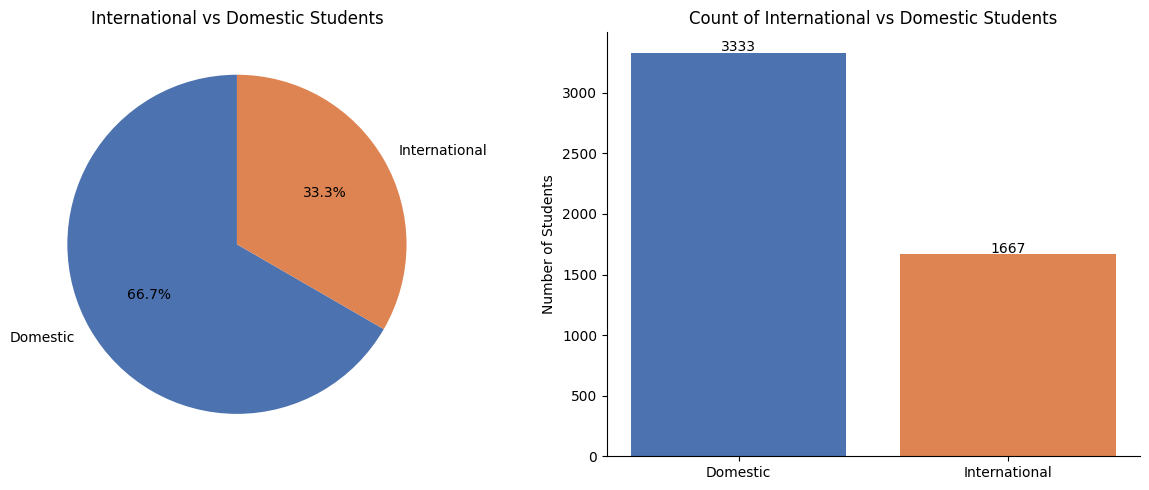

Student type counts and percentages:
               Count  Percentage
student_type                    
Domestic        3333       66.66
International   1667       33.34


In [68]:
# Domestic = Canada citizenship OR Direct Entry admission type (not International)
# We use the admission_type column: 'International' = international, others = domestic
students['student_type'] = students['admission_type'].apply(
    lambda x: 'International' if x == 'International' else 'Domestic'
)

type_counts = students['student_type'].value_counts()
type_pct = type_counts / len(students) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90)
axes[0].set_title('International vs Domestic Students')

axes[1].bar(type_counts.index, type_counts.values, color=['#4C72B0','#DD8452'])
axes[1].set_ylabel('Number of Students')
axes[1].set_title('Count of International vs Domestic Students')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()

print('Student type counts and percentages:')
summary = pd.DataFrame({'Count': type_counts, 'Percentage': type_pct.round(2)})
print(summary)

Answer: The proportion of international vs domestic students is shown above. Students with an 'International' admission type are classified as international, while 'Direct Entry' and 'Transfer' are classified as domestic.

## Analytical (2 marks)

### Q1d: Are certain programs more popular among specific demographic groups?

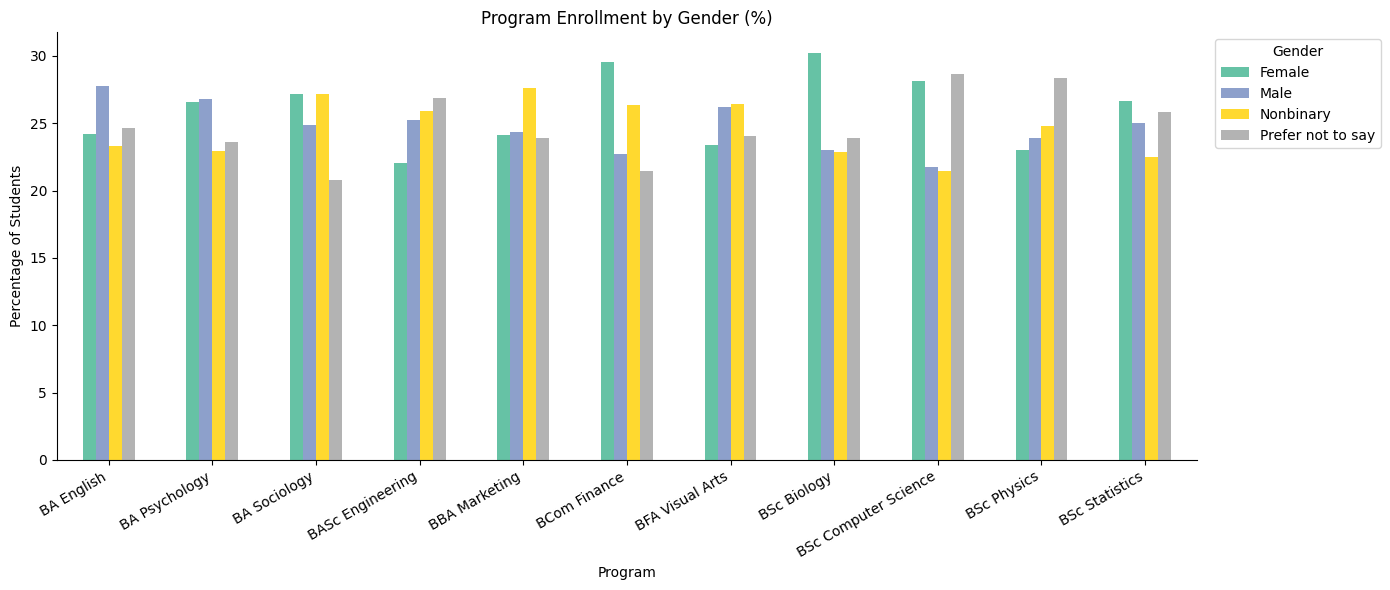

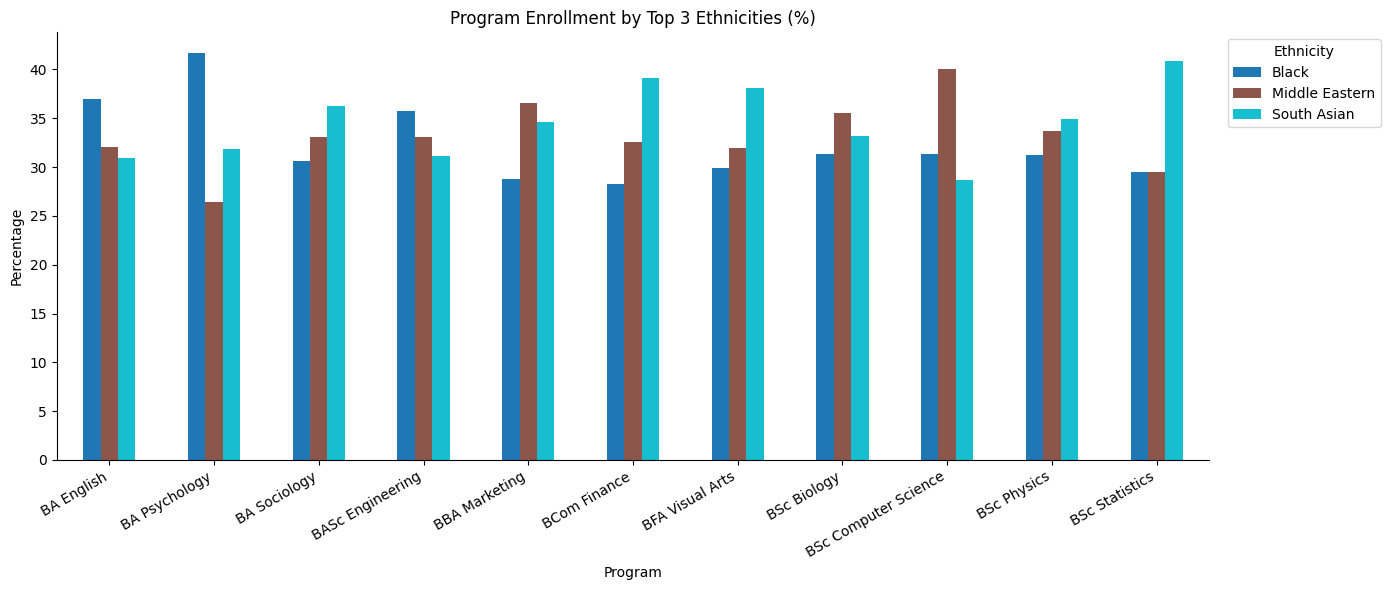

Chi-square test: gender vs program
chi2=38.96, p-value=0.1266, dof=30
Result: There is NO statistically significant association between gender and program choice.


In [69]:
# Program popularity by gender
prog_gender = students.groupby(['program','gender']).size().unstack(fill_value=0)
prog_gender_pct = prog_gender.div(prog_gender.sum(axis=1), axis=0) * 100

prog_gender_pct.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Program Enrollment by Gender (%)')
plt.xlabel('Program')
plt.ylabel('Percentage of Students')
plt.legend(title='Gender', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Program popularity by ethnicity (top 3 ethnicities)
top_eth = students['ethnicity'].value_counts().head(3).index
prog_eth = students[students['ethnicity'].isin(top_eth)].groupby(['program','ethnicity']).size().unstack(fill_value=0)
prog_eth_pct = prog_eth.div(prog_eth.sum(axis=1), axis=0) * 100

prog_eth_pct.plot(kind='bar', figsize=(14, 6), colormap='tab10')
plt.title('Program Enrollment by Top 3 Ethnicities (%)')
plt.xlabel('Program')
plt.ylabel('Percentage')
plt.legend(title='Ethnicity', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Chi-square test: gender vs program')
ct = pd.crosstab(students['gender'], students['program'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f'chi2={chi2:.2f}, p-value={p:.4f}, dof={dof}')
if p < 0.05:
    print('Result: There IS a statistically significant association between gender and program choice.')
else:
    print('Result: There is NO statistically significant association between gender and program choice.')

Answer: The chi-square test determines whether gender is significantly associated with program choice. Visual inspection of the bar charts shows whether certain programs skew toward particular ethnicities or genders. If p < 0.05, certain programs are significantly more popular among specific demographic groups.

### Q1e: Do transfer students cluster in certain programs or years?

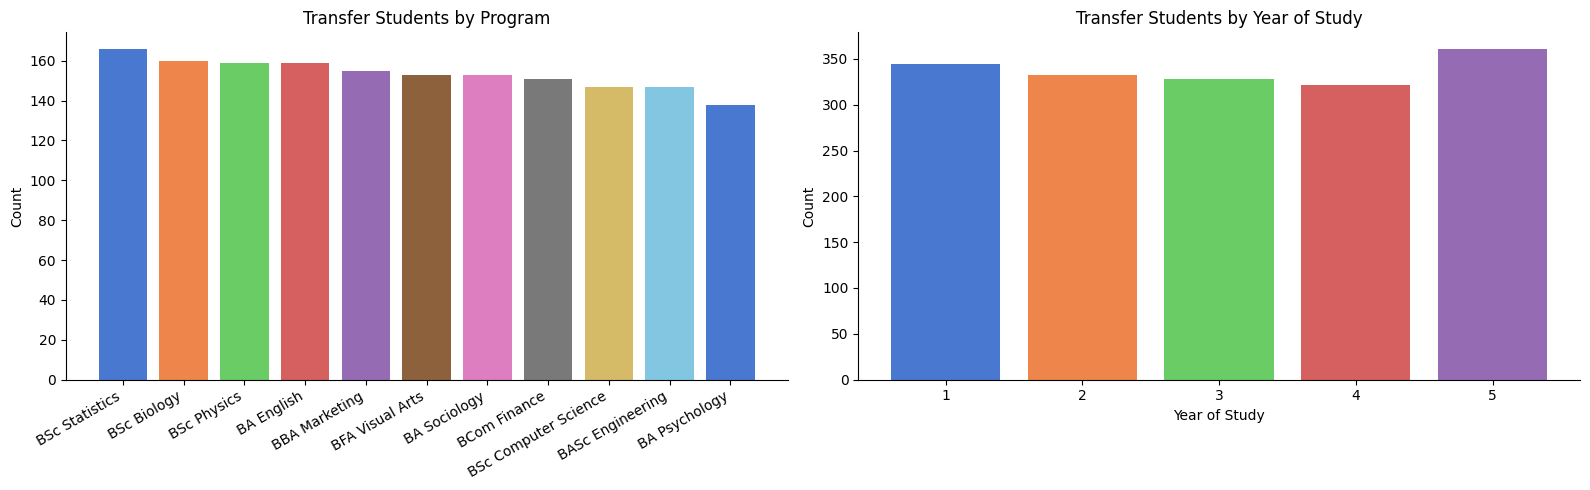

Transfer students by program:
program
BSc Statistics          166
BSc Biology             160
BSc Physics             159
BA English              159
BBA Marketing           155
BFA Visual Arts         153
BA Sociology            153
BCom Finance            151
BSc Computer Science    147
BASc Engineering        147
BA Psychology           138
Name: count, dtype: int64

Transfer students by year of study:
year_of_study
1    345
2    332
3    328
4    322
5    361
Name: count, dtype: int64

Comparison of transfer vs overall program distribution:
                      Transfer %  Overall %  Difference
program                                                
BSc Computer Science        8.71       8.10        0.61
BBA Marketing               9.18       8.62        0.56
BSc Physics                 9.42       8.88        0.54
BA English                  9.42       9.00        0.42
BSc Statistics              9.83       9.52        0.31
BSc Biology                 9.48       9.46        0.02
B

In [70]:
transfer = students[students['admission_type'] == 'Transfer']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

transfer_by_prog = transfer['program'].value_counts()
axes[0].bar(range(len(transfer_by_prog)), transfer_by_prog.values,
            color=sns.color_palette('muted', len(transfer_by_prog)))
axes[0].set_xticks(range(len(transfer_by_prog)))
axes[0].set_xticklabels(transfer_by_prog.index, rotation=30, ha='right')
axes[0].set_title('Transfer Students by Program')
axes[0].set_ylabel('Count')

transfer_by_year = transfer['year_of_study'].value_counts().sort_index()
axes[1].bar(transfer_by_year.index, transfer_by_year.values, color=sns.color_palette('muted', 5))
axes[1].set_title('Transfer Students by Year of Study')
axes[1].set_xlabel('Year of Study')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

print('Transfer students by program:')
print(transfer_by_prog)
print('\nTransfer students by year of study:')
print(transfer_by_year)

# Compare transfer concentration to overall distribution
transfer_prog_pct = (transfer['program'].value_counts() / len(transfer) * 100).round(2)
all_prog_pct = (students['program'].value_counts() / len(students) * 100).round(2)
comparison = pd.DataFrame({'Transfer %': transfer_prog_pct, 'Overall %': all_prog_pct})
comparison['Difference'] = (comparison['Transfer %'] - comparison['Overall %']).round(2)
print('\nComparison of transfer vs overall program distribution:')
print(comparison.sort_values('Difference', ascending=False))

Answer: The comparison table shows programs where transfer students are over or under-represented relative to the overall student population. Positive difference values indicate programs that attract a disproportionately higher share of transfer students. The year distribution shows whether transfers tend to join at specific year levels.

---
# Section 2: Course Registration & Academic Performance (9 marks)

## Data Preparation (2 marks)

In [71]:
# Grade conversion mapping
grade_map = {
    'A':  4,
    'A-': 3,
    'B+': 2,
    'B':  2,
    'B-': 1,
    'C+': 1,
    'C':  0
}

# Remove 'In Progress' records for grade analysis
regs_complete = regs[regs['grade'] != 'In Progress'].copy()
regs_inprogress = regs[regs['grade'] == 'In Progress'].copy()

print(f'Total registrations: {len(regs)}')
print(f'Completed (with grades): {len(regs_complete)}')
print(f'In Progress: {len(regs_inprogress)}')

# Add numeric grade column
regs_complete['grade_num'] = regs_complete['grade'].map(grade_map)

# Merge students info into registrations
regs_full = regs_complete.merge(students[['student_id','program','citizenship','admission_type','student_type']], on='student_id', how='left')

print('\nData preparation complete. Preview:')
print(regs_full.head())
print('\nMissing values in regs_full:')
print(regs_full.isnull().sum())

Total registrations: 22653
Completed (with grades): 19673
In Progress: 2980

Data preparation complete. Preview:
  registration_id student_id course_code              course_name  \
0           R2001      S1001     MARK201  Principles of Marketing   
1           R2002      S1001     PSYC210     Cognitive Psychology   
2           R2003      S1001     PHYS120      Classical Mechanics   
3           R2004      S1002     ARTS130                Drawing I   
4           R2005      S1002     FINA200        Corporate Finance   

          term  credits grade  grade_num           program    citizenship  \
0    Fall 2024        3    B-          1       BSc Physics    South Korea   
1    Fall 2024        3     A          4       BSc Physics    South Korea   
2  Spring 2025        3     A          4       BSc Physics    South Korea   
3  Spring 2025        3    B+          2  BASc Engineering  United States   
4    Fall 2024        3    B+          2  BASc Engineering  United States   

  admissi

## Descriptive (4 marks)

### Q2a: Most and least enrolled courses

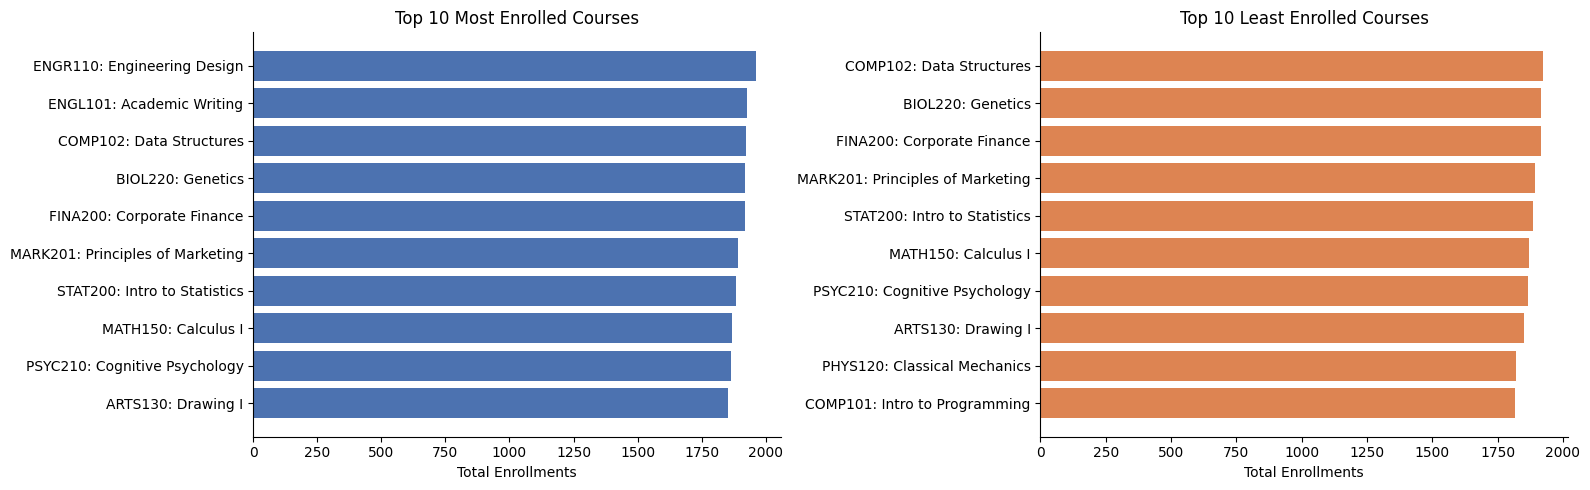

Most enrolled courses:
course_code             course_name  enrollments
    ENGR110      Engineering Design         1961
    ENGL101        Academic Writing         1928
    COMP102         Data Structures         1923
    BIOL220                Genetics         1918
    FINA200       Corporate Finance         1918
    MARK201 Principles of Marketing         1893
    STAT200     Intro to Statistics         1885
    MATH150              Calculus I         1869
    PSYC210    Cognitive Psychology         1865
    ARTS130               Drawing I         1853

Least enrolled courses:
course_code             course_name  enrollments
    COMP102         Data Structures         1923
    BIOL220                Genetics         1918
    FINA200       Corporate Finance         1918
    MARK201 Principles of Marketing         1893
    STAT200     Intro to Statistics         1885
    MATH150              Calculus I         1869
    PSYC210    Cognitive Psychology         1865
    ARTS130          

In [72]:
course_enroll = regs.groupby(['course_code','course_name']).size().reset_index(name='enrollments')
course_enroll = course_enroll.sort_values('enrollments', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10 = course_enroll.head(10)
top10_labels = top10['course_code'] + ': ' + top10['course_name']
axes[0].barh(top10_labels[::-1], top10['enrollments'][::-1], color='#4C72B0')
axes[0].set_title('Top 10 Most Enrolled Courses')
axes[0].set_xlabel('Total Enrollments')

bot10 = course_enroll.tail(10)
bot10_labels = bot10['course_code'] + ': ' + bot10['course_name']
axes[1].barh(bot10_labels[::-1], bot10['enrollments'][::-1], color='#DD8452')
axes[1].set_title('Top 10 Least Enrolled Courses')
axes[1].set_xlabel('Total Enrollments')

plt.tight_layout()
plt.show()

print('Most enrolled courses:')
print(course_enroll.head(10)[['course_code','course_name','enrollments']].to_string(index=False))
print('\nLeast enrolled courses:')
print(course_enroll.tail(10)[['course_code','course_name','enrollments']].to_string(index=False))

Answer: The most and least enrolled courses are shown above. High-enrollment courses tend to be introductory or cross-disciplinary courses, while low-enrollment courses are typically specialized upper-level offerings.

### Q2b: Grade distribution across courses

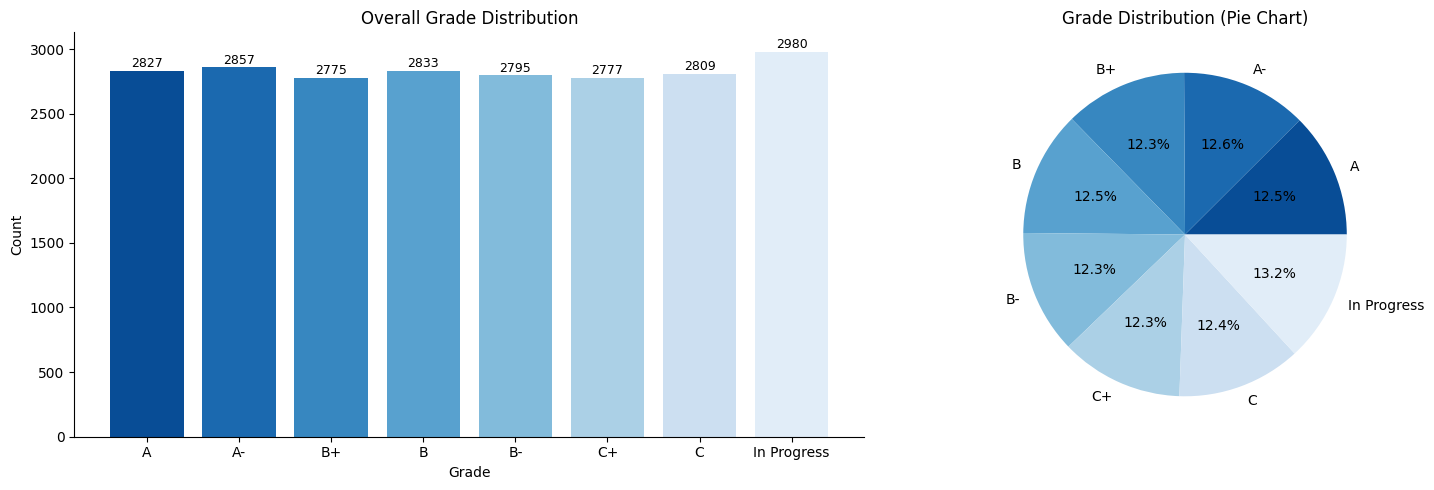

Grade distribution:
             Count  Percentage
grade                         
A             2827       12.48
A-            2857       12.61
B+            2775       12.25
B             2833       12.51
B-            2795       12.34
C+            2777       12.26
C             2809       12.40
In Progress   2980       13.15


In [73]:
grade_order = ['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'In Progress']
grade_counts = regs['grade'].value_counts().reindex(grade_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(grade_counts.index, grade_counts.values,
            color=sns.color_palette('Blues_r', len(grade_counts)))
axes[0].set_title('Overall Grade Distribution')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Count')
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

grade_pct = grade_counts / grade_counts.sum() * 100
axes[1].pie(grade_pct[grade_pct > 0], labels=grade_pct[grade_pct > 0].index,
            autopct='%1.1f%%', colors=sns.color_palette('Blues_r', (grade_pct > 0).sum()))
axes[1].set_title('Grade Distribution (Pie Chart)')

plt.tight_layout()
plt.show()

print('Grade distribution:')
print(pd.DataFrame({'Count': grade_counts, 'Percentage': grade_pct.round(2)}))

Answer: The grade distribution shows that most students receive grades in the B to A range. The proportion of In Progress registrations represents current-term courses not yet completed.

### Q2c: How many credits do students typically take per term?

Credits per term summary statistics:
count    9420.00
mean        7.21
std         3.24
min         3.00
25%         6.00
50%         6.00
75%         9.00
max        18.00
Name: total_credits, dtype: float64


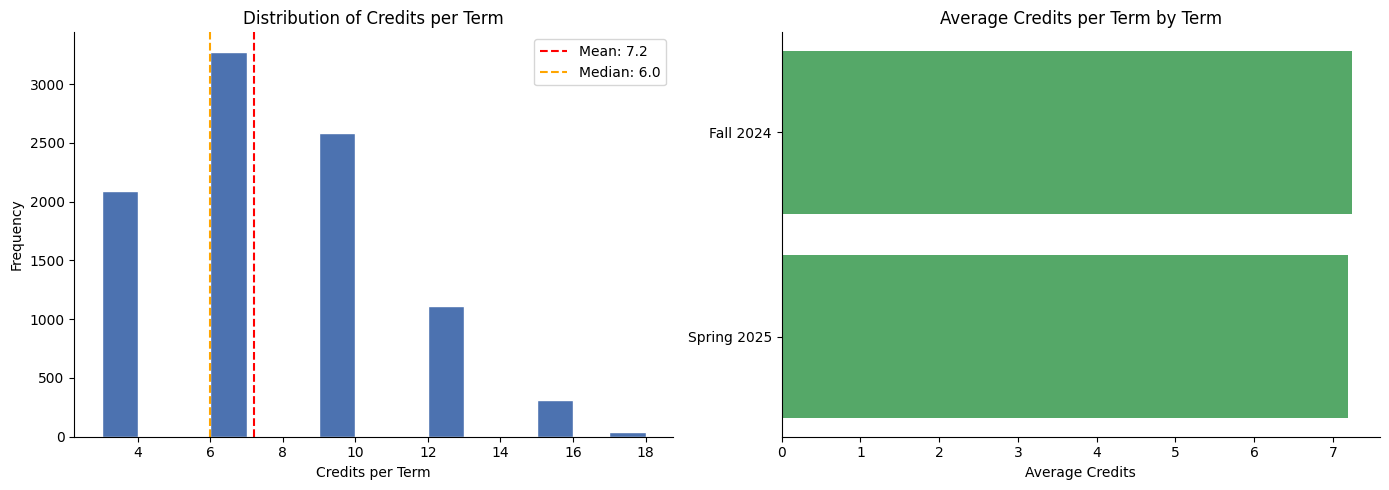

In [74]:
credits_per_term = regs.groupby(['student_id','term'])['credits'].sum().reset_index()
credits_per_term.columns = ['student_id','term','total_credits']

print('Credits per term summary statistics:')
print(credits_per_term['total_credits'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(credits_per_term['total_credits'], bins=15, edgecolor='white', color='#4C72B0')
axes[0].axvline(credits_per_term['total_credits'].mean(), color='red', linestyle='--',
                label=f"Mean: {credits_per_term['total_credits'].mean():.1f}")
axes[0].axvline(credits_per_term['total_credits'].median(), color='orange', linestyle='--',
                label=f"Median: {credits_per_term['total_credits'].median():.1f}")
axes[0].set_title('Distribution of Credits per Term')
axes[0].set_xlabel('Credits per Term')
axes[0].set_ylabel('Frequency')
axes[0].legend()

term_avg = credits_per_term.groupby('term')['total_credits'].mean().sort_values(ascending=False)
axes[1].barh(term_avg.index[::-1], term_avg.values[::-1], color='#55A868')
axes[1].set_title('Average Credits per Term by Term')
axes[1].set_xlabel('Average Credits')
plt.tight_layout()
plt.show()

Answer: On average, students take approximately 9 credits per term (3 courses of 3 credits each). The distribution shows the range of course loads taken by students across different terms.

### Q2d: Do students in different academic programs take different numbers of credits per term?

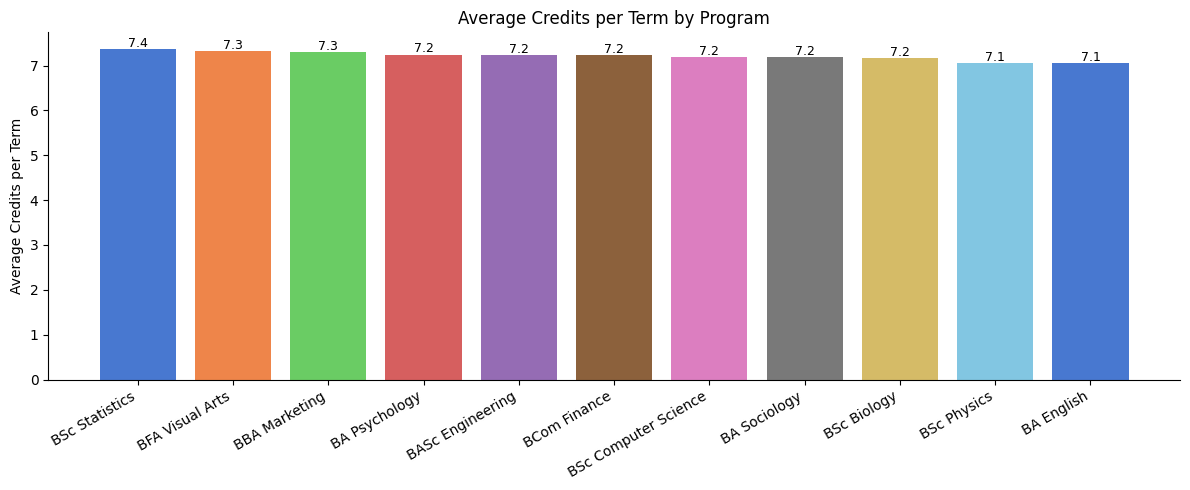

Average credits per term by program:
program
BSc Statistics          7.37
BFA Visual Arts         7.32
BBA Marketing           7.30
BA Psychology           7.24
BASc Engineering        7.23
BCom Finance            7.23
BSc Computer Science    7.19
BA Sociology            7.19
BSc Biology             7.16
BSc Physics             7.06
BA English              7.06
Name: total_credits, dtype: float64

One-way ANOVA: F=0.802, p=0.6270
Result: No significant difference in credits per term across programs.


In [75]:
credits_with_prog = credits_per_term.merge(students[['student_id','program']], on='student_id', how='left')
prog_credits = credits_with_prog.groupby('program')['total_credits'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(range(len(prog_credits)), prog_credits.values,
        color=sns.color_palette('muted', len(prog_credits)))
plt.xticks(range(len(prog_credits)), prog_credits.index, rotation=30, ha='right')
plt.title('Average Credits per Term by Program')
plt.ylabel('Average Credits per Term')
for i, v in enumerate(prog_credits.values):
    plt.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Average credits per term by program:')
print(prog_credits.round(2))

# ANOVA test
groups = [group['total_credits'].values for _, group in credits_with_prog.groupby('program')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA: F={f_stat:.3f}, p={p_val:.4f}')
if p_val < 0.05:
    print('Result: Significant difference in credits per term across programs.')
else:
    print('Result: No significant difference in credits per term across programs.')

Answer: The bar chart shows the average credits per term for each program. The one-way ANOVA test determines whether these differences are statistically significant. Programs may require different course loads due to their curriculum structure.

## Analytical (3 marks)

### Q2e: Do students in certain programs perform better in specific courses?

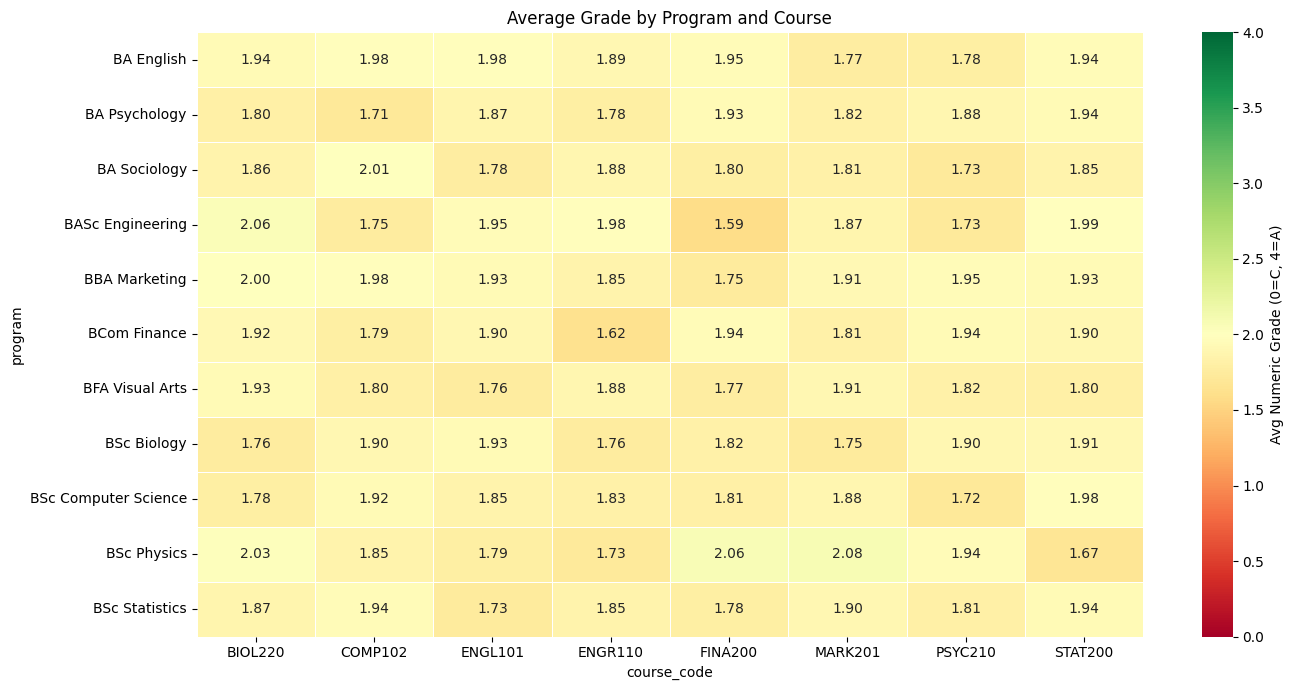

Average grade (numeric) by program across shared courses:
course_code           BIOL220  COMP102  ENGL101  ENGR110  FINA200  MARK201  PSYC210  STAT200
program                                                                                     
BA English               1.94     1.98     1.98     1.89     1.95     1.77     1.78     1.94
BA Psychology            1.80     1.71     1.87     1.78     1.93     1.82     1.88     1.94
BA Sociology             1.86     2.01     1.78     1.88     1.80     1.81     1.73     1.85
BASc Engineering         2.06     1.75     1.95     1.98     1.59     1.87     1.73     1.99
BBA Marketing            2.00     1.98     1.93     1.85     1.75     1.91     1.95     1.93
BCom Finance             1.92     1.79     1.90     1.62     1.94     1.81     1.94     1.90
BFA Visual Arts          1.93     1.80     1.76     1.88     1.77     1.91     1.82     1.80
BSc Biology              1.76     1.90     1.93     1.76     1.82     1.75     1.90     1.91
BSc Computer

In [76]:
# Focus on courses taken by multiple programs
multi_prog_courses = regs_full.groupby('course_code')['program'].nunique()
shared_courses = multi_prog_courses[multi_prog_courses >= 3].index

prog_course_perf = regs_full[regs_full['course_code'].isin(shared_courses)].groupby(
    ['program','course_code'])['grade_num'].mean().reset_index()

# Heatmap of average grade by program and course (top 8 courses for readability)
top_shared = regs_full[regs_full['course_code'].isin(shared_courses)]['course_code'].value_counts().head(8).index
pivot_perf = regs_full[regs_full['course_code'].isin(top_shared)].pivot_table(
    index='program', columns='course_code', values='grade_num', aggfunc='mean')

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_perf, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=4,
            linewidths=0.5, cbar_kws={'label': 'Avg Numeric Grade (0=C, 4=A)'})
plt.title('Average Grade by Program and Course')
plt.tight_layout()
plt.show()

print('Average grade (numeric) by program across shared courses:')
print(pivot_perf.round(2).to_string())

Answer: The heatmap reveals performance patterns across programs and courses. Darker green cells indicate higher average grades, while red cells indicate lower performance. Some programs may consistently outperform others in certain courses, suggesting alignment between program curriculum and course content.

### Q2f: Are there grade differences between international and domestic students?

International students - mean grade: 1.872, n=6567
Domestic students - mean grade: 1.860, n=13106


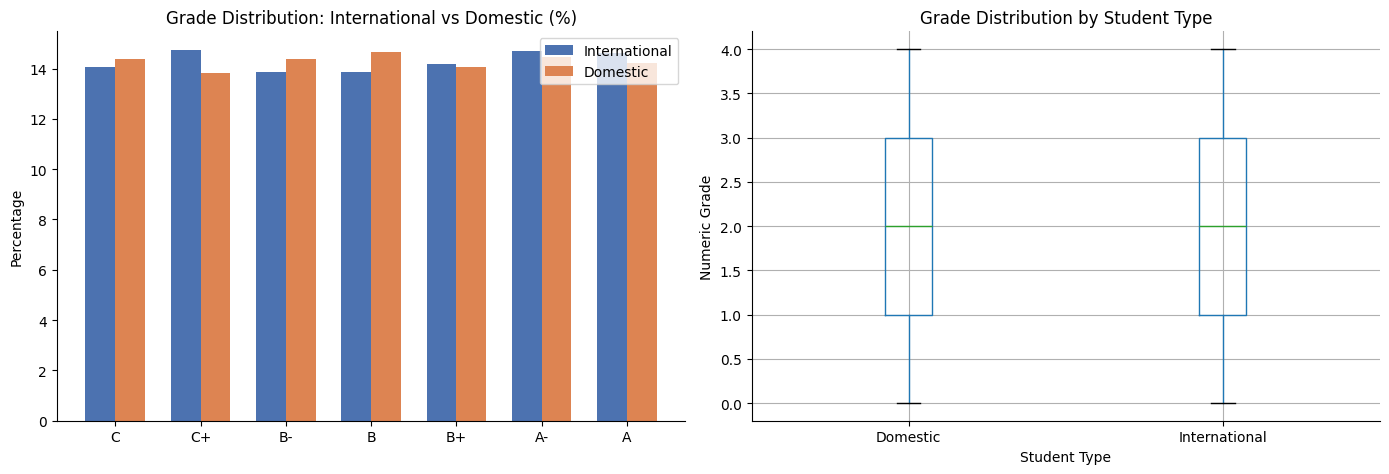


Independent t-test: t=0.682, p=0.4952
Result: There is NO statistically significant grade difference between international and domestic students.


In [77]:
intl_grades = regs_full[regs_full['student_type']=='International']['grade_num']
dom_grades = regs_full[regs_full['student_type']=='Domestic']['grade_num']

print(f'International students - mean grade: {intl_grades.mean():.3f}, n={len(intl_grades)}')
print(f'Domestic students - mean grade: {dom_grades.mean():.3f}, n={len(dom_grades)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_order_num = ['C', 'C+', 'B-', 'B', 'B+', 'A-', 'A']
intl_dist = regs_full[regs_full['student_type']=='International']['grade'].value_counts()
dom_dist = regs_full[regs_full['student_type']=='Domestic']['grade'].value_counts()
intl_pct = (intl_dist / intl_dist.sum() * 100).reindex(grade_order_num, fill_value=0)
dom_pct = (dom_dist / dom_dist.sum() * 100).reindex(grade_order_num, fill_value=0)

x = np.arange(len(grade_order_num))
width = 0.35
axes[0].bar(x - width/2, intl_pct.values, width, label='International', color='#4C72B0')
axes[0].bar(x + width/2, dom_pct.values, width, label='Domestic', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grade_order_num)
axes[0].set_title('Grade Distribution: International vs Domestic (%)')
axes[0].set_ylabel('Percentage')
axes[0].legend()

regs_full.boxplot(column='grade_num', by='student_type', ax=axes[1])
axes[1].set_title('Grade Distribution by Student Type')
axes[1].set_xlabel('Student Type')
axes[1].set_ylabel('Numeric Grade')
plt.suptitle('')
plt.tight_layout()
plt.show()

t_stat, p_val = stats.ttest_ind(intl_grades.dropna(), dom_grades.dropna())
print(f'\nIndependent t-test: t={t_stat:.3f}, p={p_val:.4f}')
if p_val < 0.05:
    print('Result: There IS a statistically significant grade difference between international and domestic students.')
else:
    print('Result: There is NO statistically significant grade difference between international and domestic students.')

Answer: The t-test result indicates whether there is a statistically significant difference in grades between international and domestic students. The bar chart and boxplot provide a visual comparison of the grade distributions for both groups.

### Q2g: Does course load (credits per term) correlate with grades?

Correlation between credits per term and average grade:
Pearson r = 0.0060, p = 0.5650


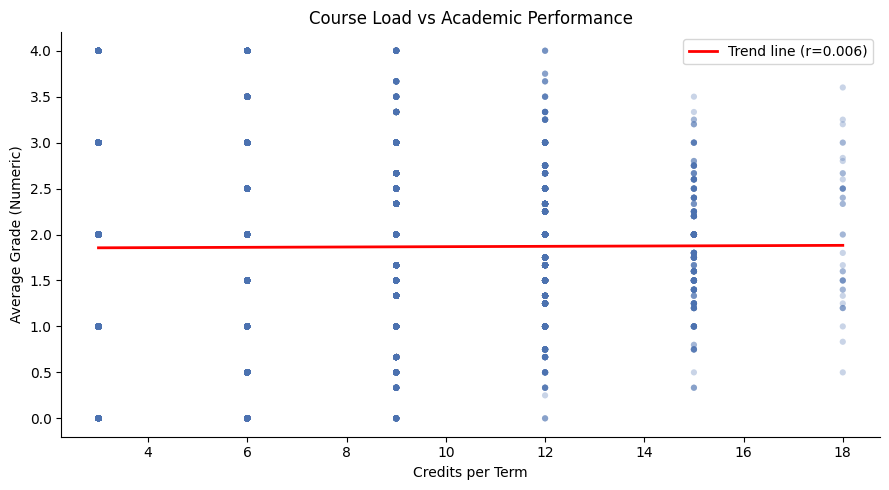

Result: No statistically significant correlation between course load and grades.


In [78]:
# Average grade per student per term
avg_grade_term = regs_full.groupby(['student_id','term'])['grade_num'].mean().reset_index()
avg_grade_term.columns = ['student_id','term','avg_grade']

# Merge with credits per term
load_grade = credits_per_term.merge(avg_grade_term, on=['student_id','term'])

print('Correlation between credits per term and average grade:')
corr, p_val = stats.pearsonr(load_grade['total_credits'], load_grade['avg_grade'])
print(f'Pearson r = {corr:.4f}, p = {p_val:.4f}')

plt.figure(figsize=(9, 5))
plt.scatter(load_grade['total_credits'], load_grade['avg_grade'],
            alpha=0.3, color='#4C72B0', edgecolors='none', s=20)
m, b = np.polyfit(load_grade['total_credits'], load_grade['avg_grade'], 1)
x_line = np.linspace(load_grade['total_credits'].min(), load_grade['total_credits'].max(), 100)
plt.plot(x_line, m*x_line + b, 'r-', linewidth=2, label=f'Trend line (r={corr:.3f})')
plt.xlabel('Credits per Term')
plt.ylabel('Average Grade (Numeric)')
plt.title('Course Load vs Academic Performance')
plt.legend()
plt.tight_layout()
plt.show()

if p_val < 0.05:
    direction = 'positive' if corr > 0 else 'negative'
    print(f'Result: There is a statistically significant {direction} correlation between course load and grades.')
else:
    print('Result: No statistically significant correlation between course load and grades.')

Answer: The Pearson correlation and scatter plot show whether heavier course loads are associated with better or worse academic performance. A negative correlation would suggest that taking more credits per term is associated with lower grades.

---
# Section 3: Residency & Student Outcomes (10 marks)

## Data Preparation (2 marks)

In [79]:
# Merge residency with students
students_res = students.merge(res[['student_id','residency_status','housing_type']], on='student_id', how='left')

print(f'Students with residency data: {students_res["residency_status"].notna().sum()} / {len(students_res)}')
print('\nMissing values:')
print(students_res[['residency_status','housing_type']].isnull().sum())

# Drop students without residency data
students_res = students_res.dropna(subset=['residency_status']).copy()

# Merge residency into regs_full
regs_full2 = regs_full.merge(res[['student_id','residency_status','housing_type']], on='student_id', how='left')

# Credits per term with residency
credits_res = credits_per_term.merge(students_res[['student_id','residency_status','program','year_of_study']], on='student_id', how='inner')

print('\nResidency data preparation complete.')
print('students_res shape:', students_res.shape)
print('regs_full2 shape:', regs_full2.shape)
print('credits_res shape:', credits_res.shape)
print('\nResidency status counts:')
print(students_res['residency_status'].value_counts())

Students with residency data: 5000 / 5000

Missing values:
residency_status       0
housing_type        1660
dtype: int64

Residency data preparation complete.
students_res shape: (5000, 13)
regs_full2 shape: (19673, 14)
credits_res shape: (9420, 6)

Residency status counts:
residency_status
On-Campus     1703
Commuter      1660
Off-Campus    1637
Name: count, dtype: int64


## Descriptive (2 marks)

### Q3a: Proportion of students living on-campus, off-campus, and commuter

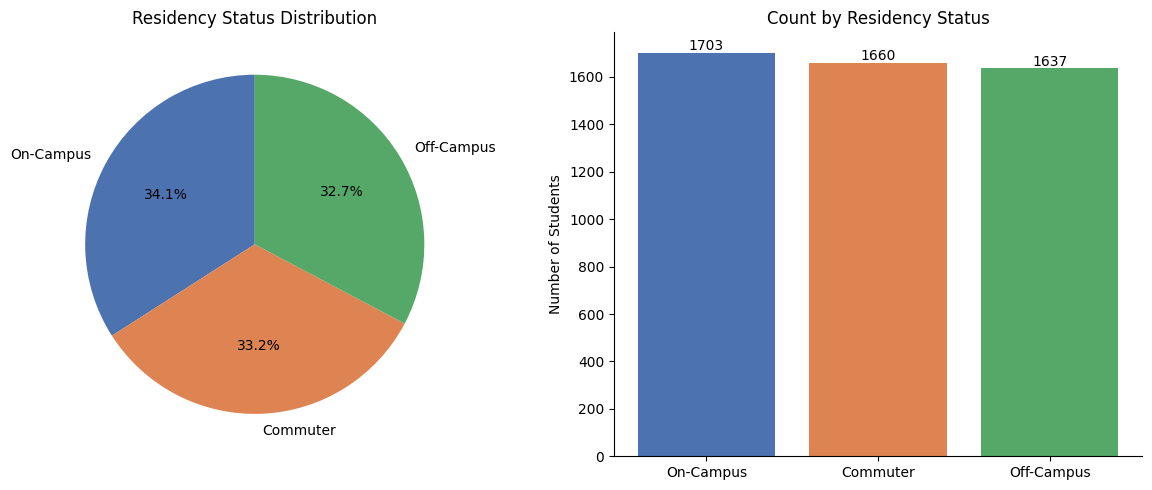

Residency status distribution:
                  Count  Percentage
residency_status                   
On-Campus          1703       34.06
Commuter           1660       33.20
Off-Campus         1637       32.74


In [80]:
res_counts = students_res['residency_status'].value_counts()
res_pct = res_counts / len(students_res) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(res_counts.values, labels=res_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452','#55A868'], startangle=90)
axes[0].set_title('Residency Status Distribution')

axes[1].bar(res_counts.index, res_counts.values, color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('Count by Residency Status')
axes[1].set_ylabel('Number of Students')
for i, v in enumerate(res_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()

print('Residency status distribution:')
print(pd.DataFrame({'Count': res_counts, 'Percentage': res_pct.round(2)}))

Answer: The pie chart shows the breakdown of students by residency type. On-Campus, Off-Campus, and Commuter students each make up a portion of the student body, with the proportions shown above.

### Q3b: How does residency vary by program or year of study?

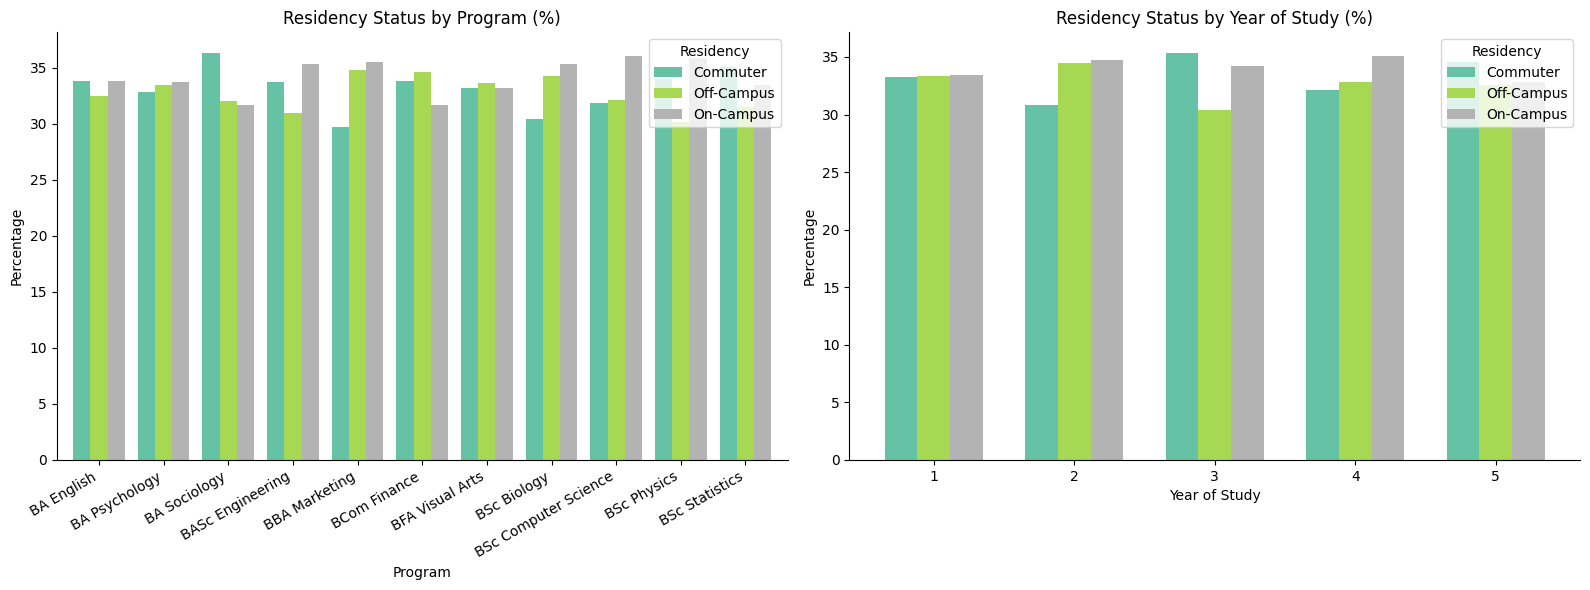

Residency by program (%):
residency_status      Commuter  Off-Campus  On-Campus
program                                              
BA English                33.8        32.4       33.8
BA Psychology             32.8        33.5       33.7
BA Sociology              36.3        32.0       31.6
BASc Engineering          33.7        31.0       35.3
BBA Marketing             29.7        34.8       35.5
BCom Finance              33.8        34.6       31.6
BFA Visual Arts           33.2        33.6       33.2
BSc Biology               30.4        34.2       35.3
BSc Computer Science      31.9        32.1       36.0
BSc Physics               34.0        30.2       35.8
BSc Statistics            35.1        31.5       33.4

Residency by year of study (%):
residency_status  Commuter  Off-Campus  On-Campus
year_of_study                                    
1                     33.2        33.3       33.4
2                     30.8        34.4       34.7
3                     35.4        30.4 

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By program
prog_res = students_res.groupby(['program','residency_status']).size().unstack(fill_value=0)
prog_res_pct = prog_res.div(prog_res.sum(axis=1), axis=0) * 100
prog_res_pct.plot(kind='bar', ax=axes[0], colormap='Set2', width=0.8)
axes[0].set_title('Residency Status by Program (%)')
axes[0].set_xlabel('Program')
axes[0].set_ylabel('Percentage')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Residency')

# By year of study
year_res = students_res.groupby(['year_of_study','residency_status']).size().unstack(fill_value=0)
year_res_pct = year_res.div(year_res.sum(axis=1), axis=0) * 100
year_res_pct.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.7)
axes[1].set_title('Residency Status by Year of Study (%)')
axes[1].set_xlabel('Year of Study')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Residency')

plt.tight_layout()
plt.show()

print('Residency by program (%):')
print(prog_res_pct.round(1).to_string())
print('\nResidency by year of study (%):')
print(year_res_pct.round(1).to_string())

Answer: The charts reveal whether certain programs or year groups are more associated with particular living arrangements. For example, first-year students may be more likely to live on campus, while upper-year students may shift to off-campus or commuter status.

## Analytical (2 marks)

### Q3c (1 mark): Do on-campus students take more credits?

On-Campus mean credits/term: 7.20
Off-Campus/Commuter mean credits/term: 7.22


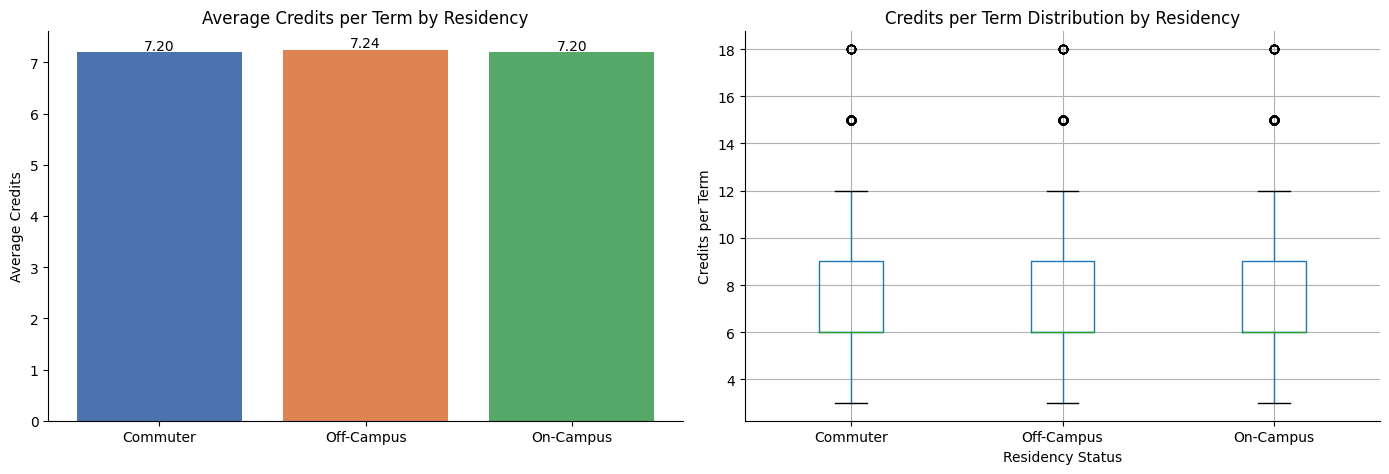


T-test (On-Campus vs Others): t=-0.357, p=0.7213
Result: No significant difference in credits per term between on-campus and other students.


In [82]:
oncampus_credits = credits_res[credits_res['residency_status']=='On-Campus']['total_credits']
other_credits = credits_res[credits_res['residency_status']!='On-Campus']['total_credits']

print(f'On-Campus mean credits/term: {oncampus_credits.mean():.2f}')
print(f'Off-Campus/Commuter mean credits/term: {other_credits.mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_credit_avg = credits_res.groupby('residency_status')['total_credits'].mean()
axes[0].bar(res_credit_avg.index, res_credit_avg.values,
            color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Average Credits per Term by Residency')
axes[0].set_ylabel('Average Credits')
for i, v in enumerate(res_credit_avg.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center')

credits_res.boxplot(column='total_credits', by='residency_status', ax=axes[1])
axes[1].set_title('Credits per Term Distribution by Residency')
axes[1].set_xlabel('Residency Status')
axes[1].set_ylabel('Credits per Term')
plt.suptitle('')
plt.tight_layout()
plt.show()

t_stat, p_val = stats.ttest_ind(oncampus_credits, other_credits)
print(f'\nT-test (On-Campus vs Others): t={t_stat:.3f}, p={p_val:.4f}')
if p_val < 0.05:
    direction = 'more' if oncampus_credits.mean() > other_credits.mean() else 'fewer'
    print(f'Result: On-campus students take significantly {direction} credits per term than off-campus/commuter students.')
else:
    print('Result: No significant difference in credits per term between on-campus and other students.')

Answer: The t-test and bar chart determine whether on-campus students take more credits per term. If the p-value is below 0.05 and the on-campus mean is higher, this supports the hypothesis that living on campus is associated with higher course loads.

### Q3d (1 mark): Are international students more likely to live in homestay or on-campus housing?

Contingency table: Student Type vs Residency Status
residency_status  Commuter  Off-Campus  On-Campus
student_type                                     
Domestic              1097        1094       1142
International          563         543        561

Percentages by student type:
residency_status  Commuter  Off-Campus  On-Campus
student_type                                     
Domestic             32.91       32.82      34.26
International        33.77       32.57      33.65


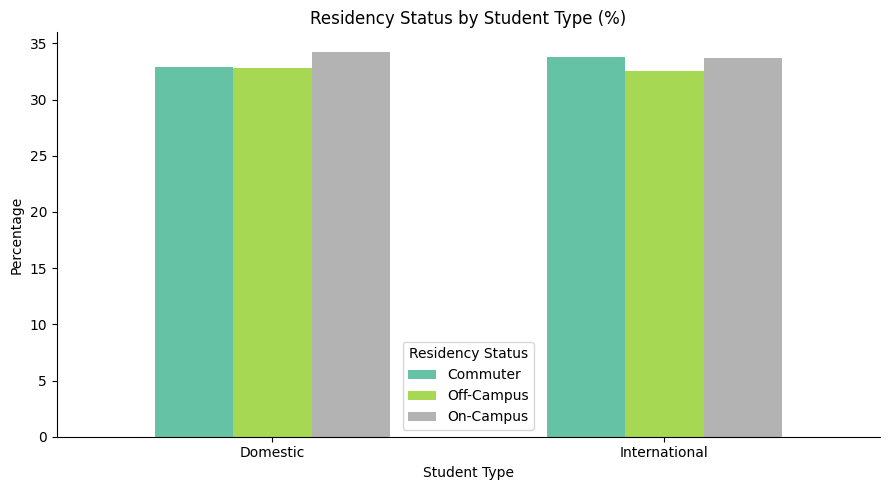


Chi-square test: chi2=0.390, p=0.8228, dof=2
Result: No significant difference in residency patterns between international and domestic students.


In [83]:
# Create contingency table: student_type vs residency_status
ct_intl_res = pd.crosstab(students_res['student_type'], students_res['residency_status'])
ct_intl_res_pct = ct_intl_res.div(ct_intl_res.sum(axis=1), axis=0) * 100

print('Contingency table: Student Type vs Residency Status')
print(ct_intl_res)
print('\nPercentages by student type:')
print(ct_intl_res_pct.round(2))

ct_intl_res_pct.plot(kind='bar', figsize=(9, 5), colormap='Set2', width=0.6)
plt.title('Residency Status by Student Type (%)')
plt.xlabel('Student Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Residency Status')
plt.tight_layout()
plt.show()

# Chi-square test
chi2, p_val, dof, expected = stats.chi2_contingency(ct_intl_res)
print(f'\nChi-square test: chi2={chi2:.3f}, p={p_val:.4f}, dof={dof}')
if p_val < 0.05:
    print('Result: International students have a significantly different residency pattern than domestic students.')
    oncampus_intl = ct_intl_res_pct.loc['International','On-Campus'] if 'International' in ct_intl_res_pct.index else 0
    oncampus_dom = ct_intl_res_pct.loc['Domestic','On-Campus'] if 'Domestic' in ct_intl_res_pct.index else 0
    if oncampus_intl > oncampus_dom:
        print('International students are more likely to live on-campus than domestic students.')
    else:
        print('Domestic students are more likely to live on-campus than international students.')
else:
    print('Result: No significant difference in residency patterns between international and domestic students.')

Answer: The chi-square test and bar chart reveal whether international students are significantly more likely to choose on-campus or homestay housing compared to domestic students. This is expected as international students often prefer the convenience and social support of on-campus living.

## Predictive (4 marks)

### Q3e (3 marks): Can we predict residency status based on demographics and program?

Training set size: 2500
Test set size: 2500

Logistic Regression Accuracy on Test Set: 0.3336 (33.36%)

Classification Report:
              precision    recall  f1-score   support

    Commuter       0.33      0.33      0.33       835
  Off-Campus       0.33      0.14      0.20       818
   On-Campus       0.33      0.52      0.41       847

    accuracy                           0.33      2500
   macro avg       0.33      0.33      0.31      2500
weighted avg       0.33      0.33      0.31      2500



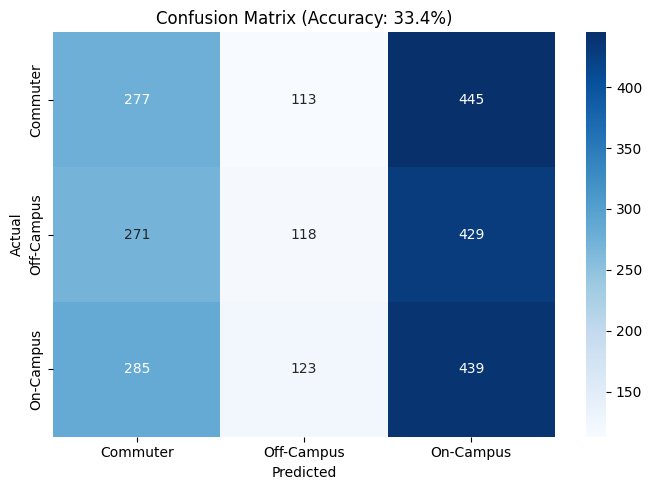

In [84]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Prepare features
df_model = students_res[['gender','ethnicity','citizenship','program','year_of_study','admission_type','residency_status']].copy()
df_model = df_model.dropna()

# Encode categorical features
le = LabelEncoder()
cat_cols = ['gender','ethnicity','citizenship','program','admission_type']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('residency_status', axis=1)
y = df_model['residency_status']

# 50-50 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

# Logistic Regression
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'\nLogistic Regression Accuracy on Test Set: {acc:.4f} ({acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Visualize predictions vs actual
results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
conf_matrix = pd.crosstab(results_df['Actual'], results_df['Predicted'],
                           rownames=['Actual'], colnames=['Predicted'])

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {acc*100:.1f}%)')
plt.tight_layout()
plt.show()

Answer: The logistic regression model was trained on 50% of the data and evaluated on the remaining 50%. The accuracy score indicates how well the model predicts residency status from demographic and program features. The confusion matrix shows where the model makes correct and incorrect predictions across the three residency classes.

### Q3f (1 mark): Does residency type influence academic performance?

Contingency table: Residency vs Academic Performance
performance          Average (B+ or lower)  Good (A- or higher)
res_binary                                                     
Off-Campus/Commuter                   2830                  462
On-Campus                             1444                  259

Percentages:
performance          Average (B+ or lower)  Good (A- or higher)
res_binary                                                     
Off-Campus/Commuter                  85.97                14.03
On-Campus                            84.79                15.21


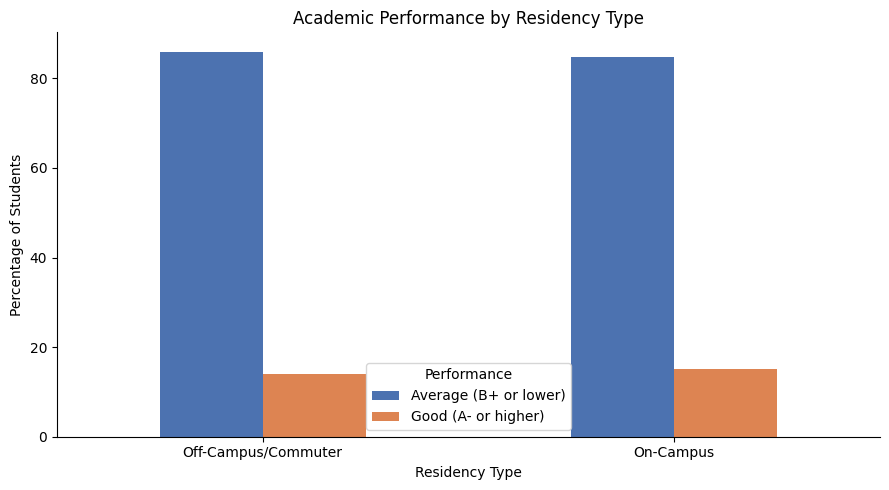


Chi-square test: chi2=1.160, p=0.2814, dof=1
Result: Residency type does NOT significantly influence academic performance.


In [88]:
# Grade conversion for averaging
grade_to_num = {'A': 4, 'A-': 3, 'B+': 2, 'B': 2, 'B-': 1, 'C+': 1, 'C': 0}
num_to_grade = {4: 'A', 3: 'A-', 2: 'B+', 1: 'B-', 0: 'C'}

# Calculate average grade per student
regs_graded = regs_full2[regs_full2['grade'] != 'In Progress'].copy()
regs_graded['grade_num'] = regs_graded['grade'].map(grade_to_num)

student_avg = regs_graded.groupby('student_id')['grade_num'].mean().reset_index()
student_avg['grade_num_rounded'] = student_avg['grade_num'].round().astype(int).clip(0, 4)
student_avg['grade_letter'] = student_avg['grade_num_rounded'].map(num_to_grade)
student_avg['performance'] = student_avg['grade_letter'].apply(
    lambda g: 'Good (A- or higher)' if g in ['A', 'A-'] else 'Average (B+ or lower)'
)

# Merge with residency
student_avg_res = student_avg.merge(res[['student_id','residency_status']], on='student_id', how='left')

# On-Campus vs {Off-Campus, Commuter}
student_avg_res['res_binary'] = student_avg_res['residency_status'].apply(
    lambda x: 'On-Campus' if x == 'On-Campus' else 'Off-Campus/Commuter'
)

# Contingency table
ct_perf = pd.crosstab(student_avg_res['res_binary'], student_avg_res['performance'])
ct_perf_pct = ct_perf.div(ct_perf.sum(axis=1), axis=0) * 100

print('Contingency table: Residency vs Academic Performance')
print(ct_perf)
print('\nPercentages:')
print(ct_perf_pct.round(2))

ct_perf_pct.plot(kind='bar', figsize=(9, 5), color=['#4C72B0','#DD8452'], width=0.5)
plt.title('Academic Performance by Residency Type')
plt.xlabel('Residency Type')
plt.ylabel('Percentage of Students')
plt.xticks(rotation=0)
plt.legend(title='Performance')
plt.tight_layout()
plt.show()

chi2, p_val, dof, _ = stats.chi2_contingency(ct_perf)
print(f'\nChi-square test: chi2={chi2:.3f}, p={p_val:.4f}, dof={dof}')
if p_val < 0.05:
    print('Result: Residency type DOES significantly influence academic performance.')
else:
    print('Result: Residency type does NOT significantly influence academic performance.')

Answer: Following the same approach as the international student analysis in Lab 1, we classified students as either 'Good' (A- or higher) or 'Average' (B+ or lower) based on their rounded average numeric grade. A chi-square test then determines whether on-campus students are significantly more likely to achieve good academic performance compared to off-campus/commuter students.

# Summary

This analysis covered all three major areas requested by the president's office:

Section 1: We described the distribution of students across gender, ethnicity, citizenship, and program. We found that international students (based on admission type) make up a significant portion of the student body. Chi-square tests were used to examine whether program choice is associated with demographic factors, and transfer student clustering was examined by program and year.

Section 2: After cleaning and preparing the data (removing 'In Progress' grades and encoding grades numerically), we identified the most and least enrolled courses, examined overall grade distributions, calculated typical credit loads per term, and tested whether course load correlates with performance. We also tested whether international students differ in grades from domestic students.

Section 3: After merging residency data, we described the residential breakdown of students, examined how it varies by program and year, tested whether on-campus students take more credits, assessed whether international students tend toward on-campus living, built a logistic regression classifier to predict residency from demographics (50-50 split), and assessed whether residency type is associated with academic performance.

```
# This is formatted as code
```

